In [1]:
# STEP 1: Import Libraries
# -----------------------------
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# STEP 2: Load Dataset
# -----------------------------
# Path to Kaggle dataset
base_path = '/kaggle/input/email-spam-classification'
file_name = os.listdir(base_path)[0]
file_path = os.path.join(base_path, file_name)

# Load CSV
df = pd.read_csv(file_path)

# Show info
print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (5172, 3002)
  Email No.  the  to  ect  and  for  of    a  you  hou  ...  connevey  jay  \
0   Email 1    0   0    1    0    0   0    2    0    0  ...         0    0   
1   Email 2    8  13   24    6    6   2  102    1   27  ...         0    0   
2   Email 3    0   0    1    0    0   0    8    0    0  ...         0    0   
3   Email 4    0   5   22    0    5   1   51    2   10  ...         0    0   
4   Email 5    7   6   17    1    5   2   57    0    9  ...         0    0   

   valued  lay  infrastructure  military  allowing  ff  dry  Prediction  
0       0    0               0         0         0   0    0           0  
1       0    0               0         0         0   1    0           0  
2       0    0               0         0         0   0    0           0  
3       0    0               0         0         0   0    0           0  
4       0    0               0         0         0   1    0           0  

[5 rows x 3002 columns]


In [3]:
# STEP 3: Feature and Target Assignment
# -----------------------------
# First column: email ID (drop)
# Last column: label (spam=1, not spam=0)
X = df.iloc[:, 1:-1]  # word counts
y = df.iloc[:, -1]    # labels

print("Feature shape:", X.shape)
print("Unique labels:", y.unique())

Feature shape: (5172, 3000)
Unique labels: [0 1]


In [4]:
# STEP 4: Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
# STEP 5: Train Multinomial Naive Bayes
# -----------------------------
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [6]:
# STEP 6: Predict
# -----------------------------
y_pred = model.predict(X_test)

Accuracy: 0.9420289855072463

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.94      0.96       735
           1       0.87      0.94      0.90       300

    accuracy                           0.94      1035
   macro avg       0.92      0.94      0.93      1035
weighted avg       0.94      0.94      0.94      1035



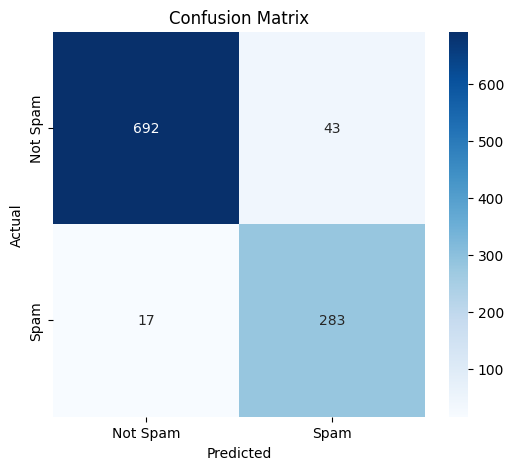

In [7]:
# STEP 7: Evaluate Model
# -----------------------------
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Spam','Spam'], yticklabels=['Not Spam','Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [8]:
# STEP 8: Conclusion
# -----------------------------
print("The model successfully classifies emails as spam or not spam using the provided labeled dataset.")

The model successfully classifies emails as spam or not spam using the provided labeled dataset.


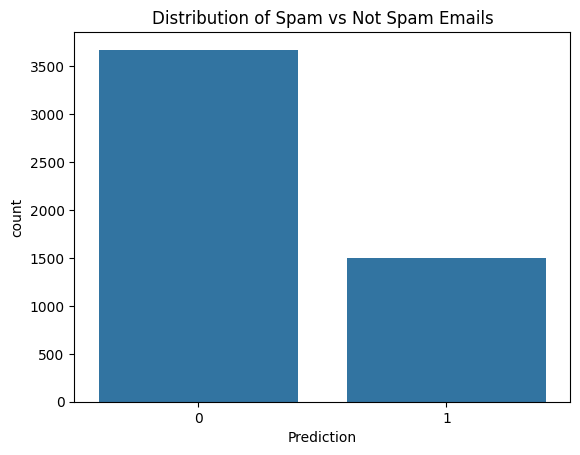

In [9]:
sns.countplot(x=y)
plt.title("Distribution of Spam vs Not Spam Emails")
plt.show()

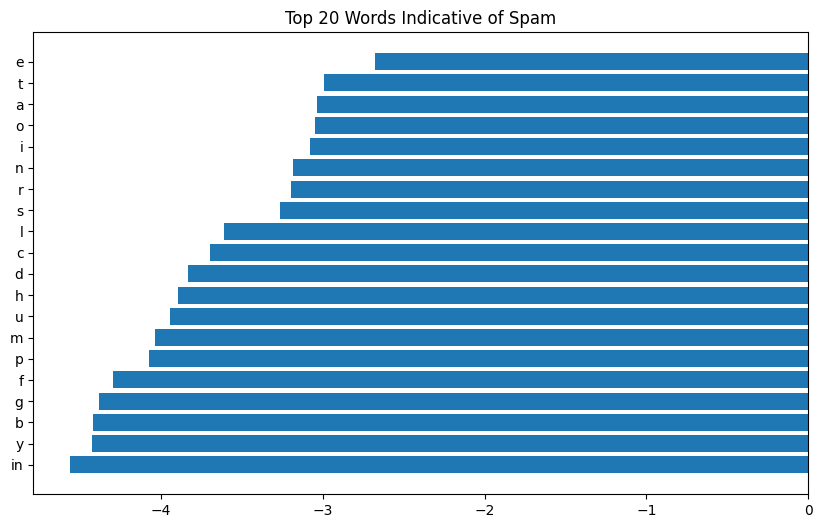

In [10]:
feature_names = X.columns
spam_class_probs = model.feature_log_prob_[1]  # log probabilities for spam
top_spam_indices = np.argsort(spam_class_probs)[-20:]  # top 20 spam words

plt.figure(figsize=(10,6))
plt.barh([feature_names[i] for i in top_spam_indices], spam_class_probs[top_spam_indices])
plt.title("Top 20 Words Indicative of Spam")
plt.show()

In [11]:
import joblib
joblib.dump(model, 'email_spam_model.pkl')

['email_spam_model.pkl']

In [12]:
model = joblib.load('email_spam_model.pkl')
